# Importing Libraries and Data

## Importing Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score
)
from sklearn import preprocessing

## Importing Data

In [5]:
#*TODO* update this path to wherever the raw data will be stored
#Import the data
data_path = "/bgfs/dgomez/dgomez/Santiago/Intro to Programming 2026/UCI Data/TCGA-PANCAN-HiSeq-801x20531"

In [15]:
rna_raw = pd.read_csv(data_path + "/data.csv")
labels = pd.read_csv(data_path + "/labels.csv")

# Exploring the Data

We can use shape to understand the dimensions and head to look at the first few rows of the data

In [16]:
#change the name of this column
labels.rename(columns={"Unnamed: 0" : "Sample"}, inplace=True)
#make the first column of rna_raw the new index
labels.set_index("Sample", inplace=True)

In [17]:
print(f"Shape of Labels: {labels.shape}")
labels.head()

Shape of Labels: (801, 1)


,Class
Sample,
sample_0,PRAD
sample_1,LUAD
sample_2,PRAD
sample_3,PRAD
sample_4,BRCA


In [18]:
#change the name of this column
rna_raw.rename(columns={"Unnamed: 0" : "Sample"}, inplace=True)
#make the first column of rna_raw the new index
rna_raw.set_index("Sample", inplace=True)

In [19]:
print(f"Shape of Counts matrix: {rna_raw.shape}")
rna_raw.head()

Shape of Counts matrix: (801, 20531)


,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,gene_9,...,gene_20521,gene_20522,gene_20523,gene_20524,gene_20525,gene_20526,gene_20527,gene_20528,gene_20529,gene_20530
Sample,,,,,,,,,,,,,,,,,,,,,
sample_0,0.0,2.017209,3.265527,5.478487,10.431999,0.0,7.175175,0.591871,0.0,0.0,...,4.926711,8.210257,9.723516,7.220030,9.119813,12.003135,9.650743,8.921326,5.286759,0.0
sample_1,0.0,0.592732,1.588421,7.586157,9.623011,0.0,6.816049,0.000000,0.0,0.0,...,4.593372,7.323865,9.740931,6.256586,8.381612,12.674552,10.517059,9.397854,2.094168,0.0
sample_2,0.0,3.511759,4.327199,6.881787,9.870730,0.0,6.972130,0.452595,0.0,0.0,...,5.125213,8.127123,10.908640,5.401607,9.911597,9.045255,9.788359,10.090470,1.683023,0.0
sample_3,0.0,3.663618,4.507649,6.659068,10.196184,0.0,7.843375,0.434882,0.0,0.0,...,6.076566,8.792959,10.141520,8.942805,9.601208,11.392682,9.694814,9.684365,3.292001,0.0
sample_4,0.0,2.655741,2.821547,6.539454,9.738265,0.0,6.566967,0.360982,0.0,0.0,...,5.996032,8.891425,10.373790,7.181162,9.846910,11.922439,9.217749,9.461191,5.110372,0.0


## Merge the dataframes to add the Cass data to the gene counts

In [24]:
rna_labeled = pd.concat([rna_raw, labels], axis=1)

print(rna_labeled.shape)
rna_labeled.head()

(801, 20532)


,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,gene_9,...,gene_20522,gene_20523,gene_20524,gene_20525,gene_20526,gene_20527,gene_20528,gene_20529,gene_20530,Class
Sample,,,,,,,,,,,,,,,,,,,,,
sample_0,0.0,2.017209,3.265527,5.478487,10.431999,0.0,7.175175,0.591871,0.0,0.0,...,8.210257,9.723516,7.220030,9.119813,12.003135,9.650743,8.921326,5.286759,0.0,PRAD
sample_1,0.0,0.592732,1.588421,7.586157,9.623011,0.0,6.816049,0.000000,0.0,0.0,...,7.323865,9.740931,6.256586,8.381612,12.674552,10.517059,9.397854,2.094168,0.0,LUAD
sample_2,0.0,3.511759,4.327199,6.881787,9.870730,0.0,6.972130,0.452595,0.0,0.0,...,8.127123,10.908640,5.401607,9.911597,9.045255,9.788359,10.090470,1.683023,0.0,PRAD
sample_3,0.0,3.663618,4.507649,6.659068,10.196184,0.0,7.843375,0.434882,0.0,0.0,...,8.792959,10.141520,8.942805,9.601208,11.392682,9.694814,9.684365,3.292001,0.0,PRAD
sample_4,0.0,2.655741,2.821547,6.539454,9.738265,0.0,6.566967,0.360982,0.0,0.0,...,8.891425,10.373790,7.181162,9.846910,11.922439,9.217749,9.461191,5.110372,0.0,BRCA


In [20]:
rna_labeled = pd.concat([rna_raw, labels], axis=1)

In [25]:
#let's confirm that this manipulation worked
print(rna_labeled.shape)
rna_labeled.head()

(801, 20532)


,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,gene_9,...,gene_20522,gene_20523,gene_20524,gene_20525,gene_20526,gene_20527,gene_20528,gene_20529,gene_20530,Class
Sample,,,,,,,,,,,,,,,,,,,,,
sample_0,0.0,2.017209,3.265527,5.478487,10.431999,0.0,7.175175,0.591871,0.0,0.0,...,8.210257,9.723516,7.220030,9.119813,12.003135,9.650743,8.921326,5.286759,0.0,PRAD
sample_1,0.0,0.592732,1.588421,7.586157,9.623011,0.0,6.816049,0.000000,0.0,0.0,...,7.323865,9.740931,6.256586,8.381612,12.674552,10.517059,9.397854,2.094168,0.0,LUAD
sample_2,0.0,3.511759,4.327199,6.881787,9.870730,0.0,6.972130,0.452595,0.0,0.0,...,8.127123,10.908640,5.401607,9.911597,9.045255,9.788359,10.090470,1.683023,0.0,PRAD
sample_3,0.0,3.663618,4.507649,6.659068,10.196184,0.0,7.843375,0.434882,0.0,0.0,...,8.792959,10.141520,8.942805,9.601208,11.392682,9.694814,9.684365,3.292001,0.0,PRAD
sample_4,0.0,2.655741,2.821547,6.539454,9.738265,0.0,6.566967,0.360982,0.0,0.0,...,8.891425,10.373790,7.181162,9.846910,11.922439,9.217749,9.461191,5.110372,0.0,BRCA


## Exploring the dataframe Column Types

In [26]:
#Pandas's columns are stored as an "Index"
print("\nColumns:")
print(rna_labeled.columns)
#And each column has a "datatype"
print("\nColumn Datatypes:")
print(rna_labeled.dtypes)
#There are two columns which are not numeric, both of which show the sample #s
print("\nHow many of each column:")
print(rna_labeled.dtypes.value_counts())


Columns:
Index(['gene_0', 'gene_1', 'gene_2', 'gene_3', 'gene_4', 'gene_5', 'gene_6',
       'gene_7', 'gene_8', 'gene_9',
       ...
       'gene_20522', 'gene_20523', 'gene_20524', 'gene_20525', 'gene_20526',
       'gene_20527', 'gene_20528', 'gene_20529', 'gene_20530', 'Class'],
      dtype='object', length=20532)

Column Datatypes:
gene_0        float64
gene_1        float64
gene_2        float64
gene_3        float64
gene_4        float64
               ...   
gene_20527    float64
gene_20528    float64
gene_20529    float64
gene_20530    float64
Class          object
Length: 20532, dtype: object

How many of each column:
float64    20531
object         1
Name: count, dtype: int64


Note that the "object" can store any datatype. In this case, it is strings encoding the Class of the tumor.

## Plot the Gene counts by Class

In [35]:
### Heatmaps represent Counts data by color

In [76]:
#first make a sample dataframe for visualization purposes
n_samples = 20
n_genes = 10
df = rna_labeled.iloc[1:n_samples,1:n_genes].copy()
#add a column so that we can plot by Sample as well
df["Sample"] = df.index.values

<Axes: xlabel='Sample', ylabel='gene_1'>

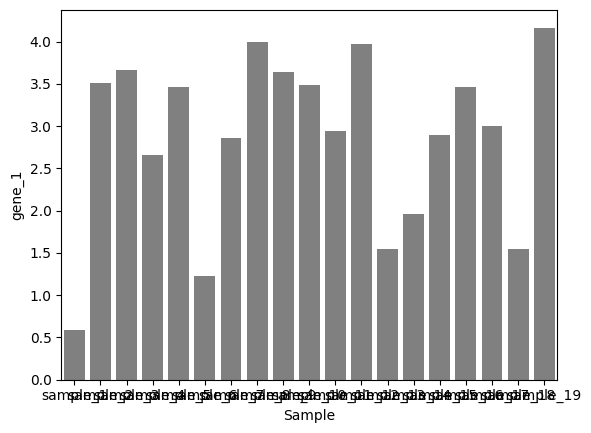

In [78]:
sns.barplot(df, x="Sample", y="gene_1", color = "gray")

In [81]:
#*TODO*: 
#have grey barchart next to colored bar chart
#have heatmap as 20 samples x gene_1

/scratch/slurm-10040807/ipykernel_3489830/708833539.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')  # Examples: 'viridis', 'plasma', 'coolwarm', 'Blues'


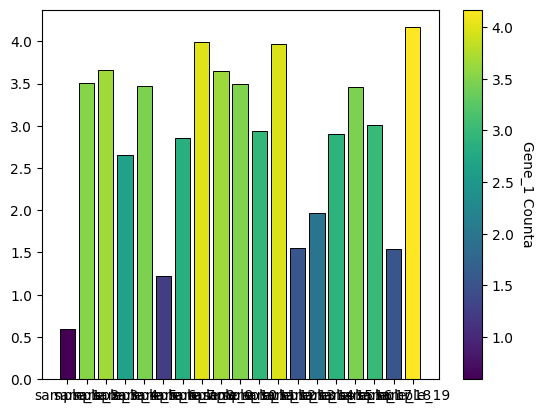

In [79]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors

fig, ax = plt.subplots()

# 3. Create a normalization object to map data to the 0-1 range
norm = mcolors.Normalize(vmin=min(df.gene_1), vmax=max(df.gene_1))

# 4. Choose a colormap and apply the normalized values to get colors
cmap = cm.get_cmap('viridis')  # Examples: 'viridis', 'plasma', 'coolwarm', 'Blues'
bar_colors = cmap(norm(df.gene_1))

# Plot the bars with the gene counts encoded as both height and colors
bars = ax.bar(df.Sample, df.gene_1, color=bar_colors, edgecolor='black', linewidth=0.7)

# Add a colorbar legend to the plot
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # Dummy array required for ScalarMappable
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('Gene_1 Counta', rotation=270, labelpad=15)

<Axes: ylabel='Sample'>

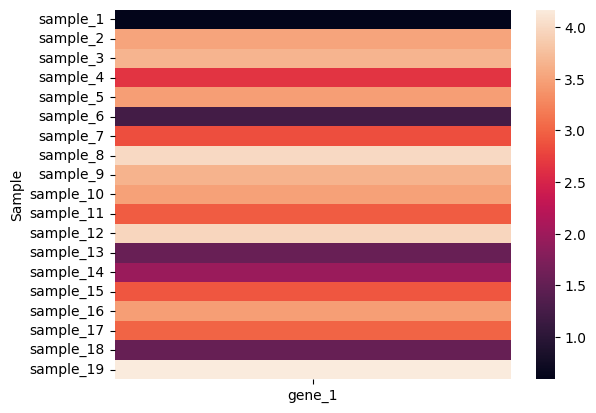

In [84]:
sns.heatmap(df.select_dtypes(include="float64").iloc[:,0:1])

<Axes: ylabel='Sample'>

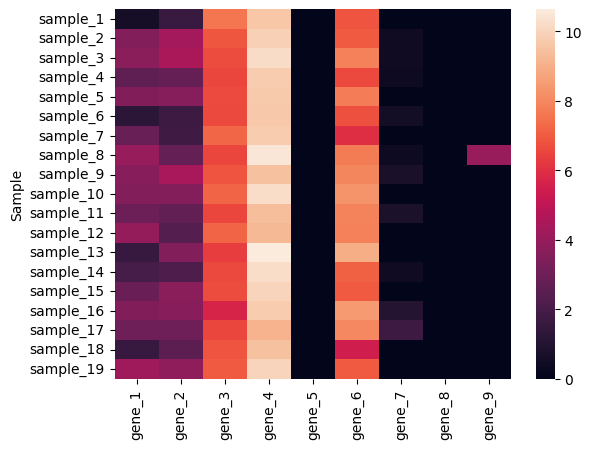

In [80]:
sns.heatmap(df.select_dtypes(include="float64"))

# Methods for Clustering the Data

In [29]:
#set the "index" of the dataframe to the "Class" column that we have just added
#note that the sample labels (ex. sample_1) are still stored in a column at the very end as "Unnamed: 0"
rna_byclass = rna_labeled.set_index("Class")

#sort the dataframe by the index that we have just created
rna_byclass.sort_index(inplace=True)

In [30]:
#Now, the index should be the Class instead of the Sample #
print(rna_byclass.shape)
rna_byclass.head()

(801, 20531)


,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,gene_9,...,gene_20521,gene_20522,gene_20523,gene_20524,gene_20525,gene_20526,gene_20527,gene_20528,gene_20529,gene_20530
Class,,,,,,,,,,,,,,,,,,,,,
BRCA,0.0,3.801873,5.025591,6.404150,9.564754,0.0,9.997688,1.025241,0.0,0.0,...,5.919628,8.507347,9.849333,8.184360,9.796564,11.607552,10.456272,9.949412,5.980037,0.000000
BRCA,0.0,3.277330,2.629846,6.000487,9.627027,0.0,8.375748,1.029559,0.0,0.0,...,6.152192,9.015499,10.244994,5.172335,9.788066,11.582057,11.098776,9.909158,5.494595,0.000000
BRCA,0.0,1.149975,0.462576,5.861427,10.092440,0.0,5.445833,1.045932,0.0,0.0,...,6.494526,9.549727,10.037602,6.636375,9.459339,10.109922,10.442394,9.574616,3.541862,0.000000
BRCA,0.0,4.538159,3.955722,6.259862,9.103243,0.0,6.918327,1.162726,0.0,0.0,...,7.102994,9.813018,10.629311,7.128757,10.409104,11.195225,11.169593,10.513451,6.729131,0.270828
BRCA,0.0,2.599770,2.562792,7.365491,10.462155,0.0,7.922370,0.000000,0.0,0.0,...,5.036873,8.267555,9.630254,5.531385,9.241642,11.459872,10.045882,9.091528,9.356654,0.000000
